<a href="https://colab.research.google.com/github/desaraju02/ai_ml_dl/blob/main/nn_with_tensorflow_regression_larger_dataset_ipynb_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [24]:
df_one_hot = pd.get_dummies(df, dtype=int)
df_one_hot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   charges           1338 non-null   float64
 4   sex_female        1338 non-null   int64  
 5   sex_male          1338 non-null   int64  
 6   smoker_no         1338 non-null   int64  
 7   smoker_yes        1338 non-null   int64  
 8   region_northeast  1338 non-null   int64  
 9   region_northwest  1338 non-null   int64  
 10  region_southeast  1338 non-null   int64  
 11  region_southwest  1338 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 125.6 KB


In [21]:
df_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


In [28]:
X = df_one_hot.drop('charges', axis=1)
y = df_one_hot['charges']

In [29]:
X

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,0,1,0,0,0,1
1,18,33.770,1,0,1,1,0,0,0,1,0
2,28,33.000,3,0,1,1,0,0,0,1,0
3,33,22.705,0,0,1,1,0,0,1,0,0
4,32,28.880,0,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,0,1,1,0,0,1,0,0
1334,18,31.920,0,1,0,1,0,1,0,0,0
1335,18,36.850,0,1,0,1,0,0,0,1,0
1336,21,25.800,0,1,0,1,0,0,0,0,1


In [30]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build a neural network

In [32]:
tf.random.set_seed(42)

In [33]:
model = tf.keras.Sequential([
    # tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])

model.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10156.6865 - mae: 10156.6865   
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7711.3110 - mae: 7711.3110  
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7388.0269 - mae: 7388.0269 
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7377.2295 - mae: 7377.2295
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7372.5176 - mae: 7372.5176 
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7323.3516 - mae: 7323.3516 
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7398.8169 - mae: 7398.8169
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7303.6562 - mae: 7303.6562 
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7274.2412 - mae: 7274.2412 
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7184.9199 - mae: 7184.9199 
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7571.5684 - mae: 7571.5684 
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━

# Check with test data

In [34]:
model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6990.1792 - mae: 6990.1792  


[6755.9306640625, 6755.9306640625]

# Trying to improve the model
i. Adding extra layer with more hidden unit ∇
ii. Train for longer

In [38]:
tf.random.set_seed(42)
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model_2.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['mae'])

model_2.fit(X_train, y_train, epochs=100)


Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 13279.3447 - mae: 13279.3447
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13158.0244 - mae: 13158.0244
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12897.4766 - mae: 12897.4766
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12350.5410 - mae: 12350.5410
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11371.4111 - mae: 11371.4111
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9988.7158 - mae: 9988.7158  
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8550.6768 - mae: 8550.6768
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7623.2749 - mae: 7623.2749
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7419.1074 - mae: 7419.1074
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7384.1460 - mae: 7384.1460
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7363.3535 - mae: 7363.3535
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 

In [39]:
model_2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5142.7344 - mae: 5142.7344  


[4985.78173828125, 4985.78173828125]

In [53]:
tf.random.set_seed(42)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),

    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)])
model_3.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['mae'])
history = model_3.fit(X_train, y_train, epochs=200)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 13279.2275 - mae: 13279.2275
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13096.0342 - mae: 13096.0342
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12745.5625 - mae: 12745.5625
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12060.2578 - mae: 12060.2578
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10911.1670 - mae: 10911.1670
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9443.3477 - mae: 9443.3477
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8099.6992 - mae: 8099.6992
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7463.6147 - mae: 7463.6147
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7368.6309 - mae: 7368.6309
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7343.0596 - mae: 7343.0596
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7320.4116 - mae: 7320.4116
Epoch 12/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s

Text(0.5, 0, 'epochs')

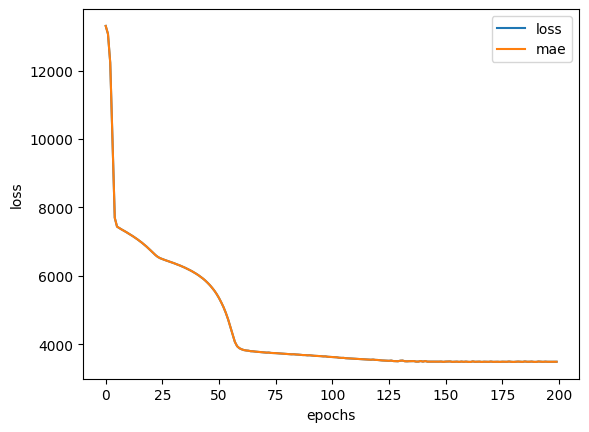

In [49]:
pd.DataFrame(history.history).plot()
plt.ylabel('loss')
plt.xlabel('epochs')

In [54]:
first_row = df_one_hot.drop('charges', axis=1).iloc[0].values.reshape(1, -1)
print(first_row)
print(df_one_hot['charges'].iloc[0])
print
predicted_charge = model_3.predict(first_row)
print(predicted_charge)
print(f"Predicted charge for the first row: {predicted_charge[0][0]}")

[[19.  27.9  0.   1.   0.   0.   1.   0.   0.   0.   1. ]]
16884.924
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
[[24178.52]]
Predicted charge for the first row: 24178.51953125


Epoch 1/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 12687.9072 - mae: 12687.9072 - val_loss: 12584.4951 - val_mae: 12584.4951
Epoch 2/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12595.5518 - mae: 12595.5518 - val_loss: 12459.9482 - val_mae: 12459.9482
Epoch 3/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12447.2441 - mae: 12447.2441 - val_loss: 12228.3770 - val_mae: 12228.3770
Epoch 4/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12171.7500 - mae: 12171.7500 - val_loss: 11813.0107 - val_mae: 11813.0107
Epoch 5/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11690.0635 - mae: 11690.0635 - val_loss: 11132.7822 - val_mae: 11132.7822
Epoch 6/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10925.4375 - mae: 10925.4375 - val_loss: 10148.2490 - val_mae: 10148.2490
Epoch 7/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9875.9785 - mae: 9875.9785 - val_loss: 9041.6660 - val_mae: 9041.6660
Epoch 8/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8695.6855 - m

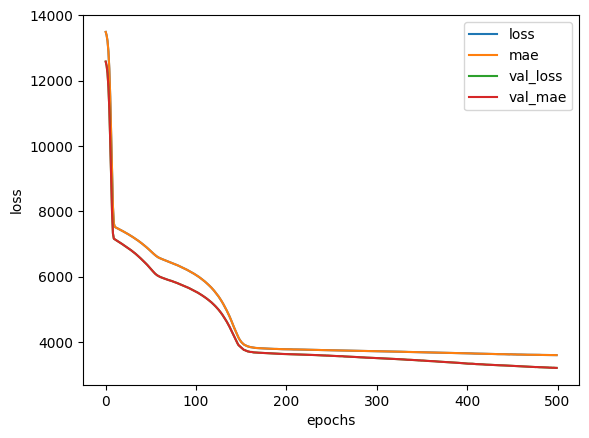

In [55]:
# prompt: Update above model with early stopping callback

# Set random seed for reproducibility
tf.random.set_seed(42)

# Build a neural network
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Compile the model
model_4.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['mae'])

# Define early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

# Train the model with early stopping
history_4 = model_4.fit(X_train, y_train, epochs=500, validation_split=0.2, callbacks=[early_stopping])

# Evaluate the model
model_4.evaluate(X_test, y_test)

# Plot the training history
pd.DataFrame(history_4.history).plot()
plt.ylabel('loss')
plt.xlabel('epochs')
plt.show()

In [56]:
first_row = df_one_hot.drop('charges', axis=1).iloc[0].values.reshape(1, -1)
print(first_row)
print(df_one_hot['charges'].iloc[0])
print
predicted_charge = model_3.predict(first_row)
print(predicted_charge)
print(f"Predicted charge for the first row: {predicted_charge[0][0]}")

[[19.  27.9  0.   1.   0.   0.   1.   0.   0.   0.   1. ]]
16884.924
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
[[24178.52]]
Predicted charge for the first row: 24178.51953125


# Preprocessing data (Normalization and Standardization)

In [57]:
X

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,0,1,0,0,0,1
1,18,33.770,1,0,1,1,0,0,0,1,0
2,28,33.000,3,0,1,1,0,0,0,1,0
3,33,22.705,0,0,1,1,0,0,1,0,0
4,32,28.880,0,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,0,1,1,0,0,1,0,0
1334,18,31.920,0,1,0,1,0,1,0,0,0
1335,18,36.850,0,1,0,1,0,0,0,1,0
1336,21,25.800,0,1,0,1,0,0,0,0,1


In [58]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

In [59]:
ct = make_column_transformer(
    (MinMaxScaler(), ['age', 'bmi', 'children']),
    (OneHotEncoder(handle_unknown='ignore'), ['sex', 'smoker', 'region'])
)

In [60]:
X1 = df.drop('charges', axis=1)
y1 = df['charges']

In [61]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [62]:
ct.fit(X1_train)

ColumnTransformer(transformers=[('minmaxscaler', MinMaxScaler(),
                                 ['age', 'bmi', 'children']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])

In [63]:
X1_train_normal = ct.transform(X1_train)
X1_test_normal = ct.transform(X1_test)

In [64]:
X1_train_normal

array([[0.60869565, 0.10734463, 0.4       , ..., 1.        , 0.        ,
        0.        ],
       [0.63043478, 0.22491256, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.73913043, 0.23944041, 0.        , ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.86956522, 0.24791499, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.41304348, 0.85122411, 0.4       , ..., 0.        , 0.        ,
        1.        ],
       [0.80434783, 0.37503363, 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [65]:
X1_train_normal.shape

(1070, 11)

# Train with the normalized data

Epoch 1/250
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 12693.7783 - mae: 12693.7783 - val_loss: 12651.7002 - val_mae: 12651.7002
Epoch 2/250
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12689.0273 - mae: 12689.0273 - val_loss: 12643.8027 - val_mae: 12643.8027
Epoch 3/250
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12679.2998 - mae: 12679.2998 - val_loss: 12627.4092 - val_mae: 12627.4092
Epoch 4/250
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12659.7666 - mae: 12659.7666 - val_loss: 12597.3350 - val_mae: 12597.3350
Epoch 5/250
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12625.0723 - mae: 12625.0723 - val_loss: 12547.8379 - val_mae: 12547.8379
Epoch 6/250
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12569.3398 - mae: 12569.3398 - val_loss: 12473.0166 - val_mae: 12473.0166
Epoch 7/250
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12486.7480 - mae: 12486.7480 - val_loss: 12367.4570 - val_mae: 12367.4570
Epoch 8/250
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12371.949

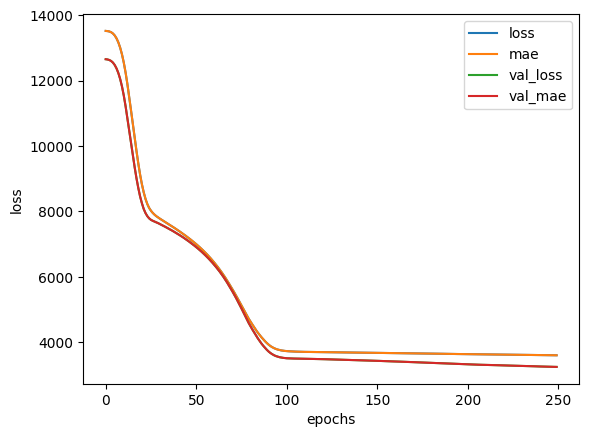

In [66]:
# Set random seed for reproducibility
tf.random.set_seed(42)

# Build a neural network
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Compile the model
model_5.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['mae'])

# Define early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

# Train the model with early stopping
history_5 = model_5.fit(X1_train_normal, y1_train, epochs=250, validation_split=0.2, callbacks=[early_stopping])

# Evaluate the model
model_5.evaluate(X1_test_normal, y1_test)

# Plot the training history
pd.DataFrame(history_5.history).plot()
plt.ylabel('loss')
plt.xlabel('epochs')
plt.show()

In [68]:
first_row = df_one_hot.drop('charges', axis=1).iloc[0].values.reshape(1, -1)
print(first_row)
print(df_one_hot['charges'].iloc[0])
print
predicted_charge = model_5.predict(first_row)
print(predicted_charge)
print(f"Predicted charge for the first row: {predicted_charge[0][0]}")

[[19.  27.9  0.   1.   0.   0.   1.   0.   0.   0.   1. ]]
16884.924
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[[309638.8]]
Predicted charge for the first row: 309638.8125
